In [2]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.6 MB/s eta 0:00:00


Giá_cần_phải_trả:266,074 VND
Điểm_nhận_được_khi_shipper_hoàn_thành_đơn_hàng:8.31


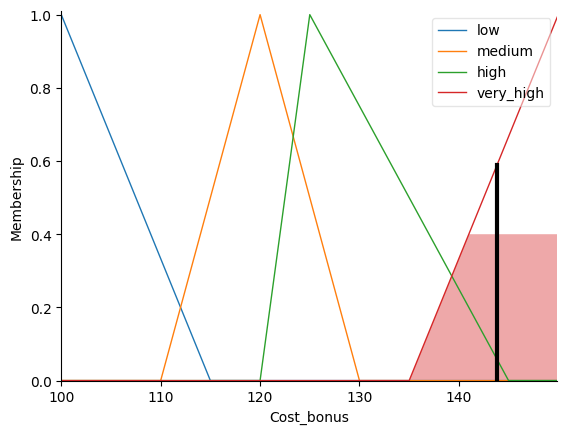

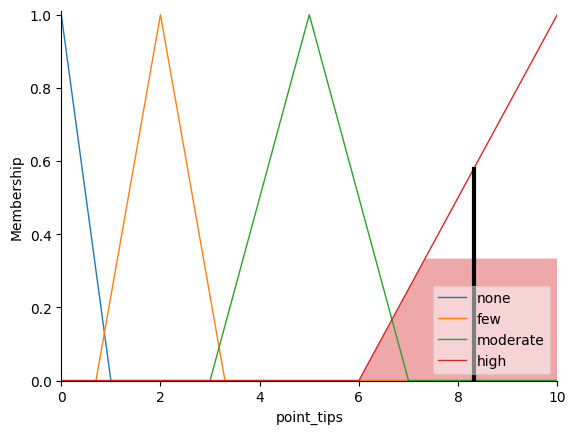

In [3]:
#Bài tập 2.11
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np

Ride_Distance=ctrl.Antecedent(np.arange(0,50.1,0.1),"Ride_Distance")
Traffic_Condition=ctrl.Antecedent(np.arange(0,100.1,0.1),"Traffic_Condition")
Demand_Level=ctrl.Antecedent(np.arange(0,100.1,0.1),"Demand_Level")
Weather_Condition=ctrl.Antecedent(np.arange(0,10.1,0.1),"Weather_Condition")
Customer_Rating=ctrl.Antecedent(np.arange(1,5.1,0.1),"Customer_Rating")
Ride_Punctuality=ctrl.Antecedent(np.arange(0,100.1,0.1),"Ride_Punctuality")
Cost_bonus=ctrl.Consequent(np.arange(100,150,0.1),"Cost_bonus")
point_tips=ctrl.Consequent(np.arange(0,10.1,0.1),"point_tips")

Ride_Distance["short"]=fuzz.trimf(Ride_Distance.universe,[0,0,3])
Ride_Distance["medium"]=fuzz.trimf(Ride_Distance.universe,[2,5,8])
Ride_Distance["long"]=fuzz.trimf(Ride_Distance.universe,[6,13,20])
Ride_Distance["very_long"]=fuzz.trimf(Ride_Distance.universe,[15,50,50])

Traffic_Condition["low"]=fuzz.trimf(Traffic_Condition.universe,[0,0,30])
Traffic_Condition["medium"]=fuzz.trimf(Traffic_Condition.universe,[20,45,70])
Traffic_Condition["high"]=fuzz.trimf(Traffic_Condition.universe,[60,100,100])

Demand_Level["low"]=fuzz.trimf(Demand_Level.universe,[0,0,30])
Demand_Level["medium"]=fuzz.trimf(Demand_Level.universe,[20,45,70])
Demand_Level["high"]=fuzz.trimf(Demand_Level.universe,[60,100,100])

Weather_Condition["bad"]=fuzz.trimf(Weather_Condition.universe,[0,0,5])
Weather_Condition["moderate"]=fuzz.trimf(Weather_Condition.universe,[4,6,8])
Weather_Condition["good"]=fuzz.trimf(Weather_Condition.universe,[7,10,10])

Customer_Rating["poor"]=fuzz.trimf(Customer_Rating.universe,[1,1,2.5])
Customer_Rating["average"]=fuzz.trimf(Customer_Rating.universe,[2,3,4])
Customer_Rating["good"]=fuzz.trimf(Customer_Rating.universe,[3.5,5,5])

Ride_Punctuality["late"]=fuzz.trimf(Ride_Punctuality.universe,[0,0,50])
Ride_Punctuality["on_time"]=fuzz.trimf(Ride_Punctuality.universe,[40,60,80])
Ride_Punctuality["early"]=fuzz.trimf(Ride_Punctuality.universe,[70,100,100])

Cost_bonus["low"]=fuzz.trimf(Cost_bonus.universe,[100,100,115])
Cost_bonus["medium"]=fuzz.trimf(Cost_bonus.universe,[110,120,130])
Cost_bonus["high"]=fuzz.trimf(Cost_bonus.universe,[120,125,145])
Cost_bonus["very_high"]=fuzz.trimf(Cost_bonus.universe,[135,150,150])

point_tips["none"]=fuzz.trimf(point_tips.universe,[0,0,1])
point_tips["few"]=fuzz.trimf(point_tips.universe,[0.7,2,3.3])
point_tips["moderate"]=fuzz.trimf(point_tips.universe,[3,5,7])
point_tips["high"]=fuzz.trimf(point_tips.universe,[6,10,10])

Rules = [
    ctrl.Rule(Ride_Distance["short"] & Traffic_Condition["low"] & Demand_Level["low"], Cost_bonus["low"]),
    ctrl.Rule(Ride_Distance["short"] & Traffic_Condition["medium"] & Demand_Level["high"], Cost_bonus["medium"]),
    ctrl.Rule(Ride_Distance["medium"] & Traffic_Condition["high"] & Demand_Level["high"], Cost_bonus["high"]),
    ctrl.Rule(Ride_Distance["long"] & Traffic_Condition["medium"] & Weather_Condition["good"], Cost_bonus["medium"]),
    ctrl.Rule(Ride_Distance["long"] & Traffic_Condition["high"] & Weather_Condition["bad"], Cost_bonus["very_high"]),
    ctrl.Rule(Ride_Distance["very_long"] & Traffic_Condition["high"] & Demand_Level["high"], Cost_bonus["very_high"]),
    ctrl.Rule(Ride_Distance["medium"] & Traffic_Condition["low"] & Demand_Level["low"], Cost_bonus["medium"]),
    ctrl.Rule(Ride_Distance["short"] & Traffic_Condition["high"] & Weather_Condition["bad"], Cost_bonus["high"]),
    ctrl.Rule(Ride_Distance["very_long"] & Weather_Condition["bad"], Cost_bonus["very_high"]),
    ctrl.Rule(Ride_Distance["medium"] & Traffic_Condition["medium"] & Weather_Condition["moderate"], Cost_bonus["medium"]),

    ctrl.Rule(Customer_Rating["good"] & Ride_Punctuality["early"], point_tips["high"]),
    ctrl.Rule(Customer_Rating["average"] & Ride_Punctuality["on_time"], point_tips["moderate"]),
    ctrl.Rule(Customer_Rating["poor"], point_tips["none"]),
    ctrl.Rule(Ride_Distance["long"] & Traffic_Condition["high"] & Ride_Punctuality["on_time"], point_tips["high"]),
    ctrl.Rule(Ride_Distance["medium"] & Traffic_Condition["medium"] & Customer_Rating["good"], point_tips["moderate"]),
    ctrl.Rule(Customer_Rating["poor"] & Ride_Punctuality["late"], point_tips["none"]),
    ctrl.Rule(Ride_Distance["very_long"] & Weather_Condition["bad"] & Customer_Rating["good"], point_tips["high"]),
    ctrl.Rule(Ride_Distance["short"] & Customer_Rating["average"] & Ride_Punctuality["on_time"], point_tips["few"]),
    ctrl.Rule(Ride_Distance["long"] & Traffic_Condition["high"] & Ride_Punctuality["late"], point_tips["few"]) ,
    ctrl.Rule(Ride_Distance["medium"] & Weather_Condition["moderate"] & Customer_Rating["good"], point_tips["moderate"]),
    ]

Rule_app_ctrl=ctrl.ControlSystem(Rules)
evaluation=ctrl.ControlSystemSimulation(Rule_app_ctrl)

evaluation.input["Ride_Distance"]=37
evaluation.input["Traffic_Condition"]=55
evaluation.input["Demand_Level"]=17
evaluation.input["Weather_Condition"]=3
evaluation.input["Customer_Rating"]=4
evaluation.input["Ride_Punctuality"]=70

evaluation.compute()

he_so_thuong = evaluation.output["Cost_bonus"]
quang_duong = 37
gia_cuoi_cung = he_so_thuong/100 * quang_duong * 5000

print(f"Giá_cần_phải_trả:{gia_cuoi_cung:,.0f} VND")
print(f"Điểm_nhận_được_khi_shipper_hoàn_thành_đơn_hàng:{evaluation.output["point_tips"]:.2f}")
Cost_bonus.view(sim=evaluation)
point_tips.view(sim=evaluation)

Tỷ lệ chiết khấu khuyến nghị: 57.38%


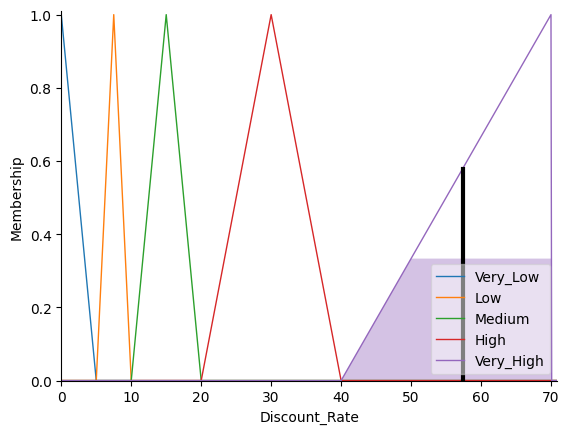

In [5]:
#Bài tập 2.12
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np

Store_Rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), "Store_Rating")
Sales_Volume = ctrl.Antecedent(np.arange(0, 101, 1), "Sales_Volume")
Profit_Margin = ctrl.Antecedent(np.arange(0, 101, 1), "Profit_Margin")
Seasonal_Event = ctrl.Antecedent(np.arange(0, 11, 1), "Seasonal_Event")
Competitor_Discount = ctrl.Antecedent(np.arange(0, 101, 1), "Competitor_Discount")
Discount_Rate = ctrl.Consequent(np.arange(0, 71, 0.1), "Discount_Rate")

Store_Rating['Low'] = fuzz.trimf(Store_Rating.universe, [0, 0, 4])
Store_Rating['Medium'] = fuzz.trimf(Store_Rating.universe, [4, 4.2, 4.5])
Store_Rating['High'] = fuzz.trimf(Store_Rating.universe, [4.5, 5, 5])

Sales_Volume['Low'] = fuzz.trimf(Sales_Volume.universe, [0, 0, 40])
Sales_Volume['Medium'] = fuzz.trimf(Sales_Volume.universe, [30, 50, 70])
Sales_Volume['High'] = fuzz.trimf(Sales_Volume.universe, [60, 100, 100])

Profit_Margin['Low'] = fuzz.trimf(Profit_Margin.universe, [0, 0, 20])
Profit_Margin['Medium'] = fuzz.trimf(Profit_Margin.universe, [15, 30, 50])
Profit_Margin['High'] = fuzz.trimf(Profit_Margin.universe, [40, 100, 100])

Seasonal_Event['None'] = fuzz.trimf(Seasonal_Event.universe, [0, 0, 3])
Seasonal_Event['Moderate'] = fuzz.trimf(Seasonal_Event.universe, [2, 5, 8])
Seasonal_Event['High'] = fuzz.trimf(Seasonal_Event.universe, [7, 10, 10])

Competitor_Discount['Low'] = fuzz.trimf(Competitor_Discount.universe, [0, 0, 15])
Competitor_Discount['Medium'] = fuzz.trimf(Competitor_Discount.universe, [10, 25, 40])
Competitor_Discount['High'] = fuzz.trimf(Competitor_Discount.universe, [35, 100, 100])

Discount_Rate['Very_Low'] = fuzz.trimf(Discount_Rate.universe, [0, 0, 5])
Discount_Rate['Low'] = fuzz.trimf(Discount_Rate.universe, [5, 7.5, 10])
Discount_Rate['Medium'] = fuzz.trimf(Discount_Rate.universe, [10, 15, 20])
Discount_Rate['High'] = fuzz.trimf(Discount_Rate.universe, [20, 30, 40])
Discount_Rate['Very_High'] = fuzz.trimf(Discount_Rate.universe, [40, 70, 70])

rules = [
    ctrl.Rule(Store_Rating['High'] & Sales_Volume['High'] & Profit_Margin['High'], Discount_Rate['Very_Low']),
    ctrl.Rule(Store_Rating['Low'] & Sales_Volume['Low'] & Profit_Margin['High'], Discount_Rate['High']),
    ctrl.Rule(Seasonal_Event['High'] & Competitor_Discount['High'], Discount_Rate['Very_High']),
    ctrl.Rule(Store_Rating['Medium'] & Sales_Volume['Medium'] & Profit_Margin['Medium'], Discount_Rate['Medium']),
    ctrl.Rule(Competitor_Discount['Low'] & Profit_Margin['Low'] & Sales_Volume['High'], Discount_Rate['Very_Low']),
    ctrl.Rule(Store_Rating['Low'] & Seasonal_Event['None'] , Discount_Rate['Medium']),
    ctrl.Rule(Sales_Volume['Low'] & Profit_Margin['Low'] , Discount_Rate['Very_High']),

]

discount_ctrl = ctrl.ControlSystem(rules)
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

discount_sim.input['Store_Rating'] = 4.3
discount_sim.input['Sales_Volume'] = 45
discount_sim.input['Profit_Margin'] = 15
discount_sim.input['Seasonal_Event'] = 8
discount_sim.input['Competitor_Discount'] = 60

discount_sim.compute()

print(f"Tỷ lệ chiết khấu khuyến nghị: {discount_sim.output['Discount_Rate']:.2f}%")

Discount_Rate.view(sim=discount_sim)

Recommended Discount Rate: 31.36%


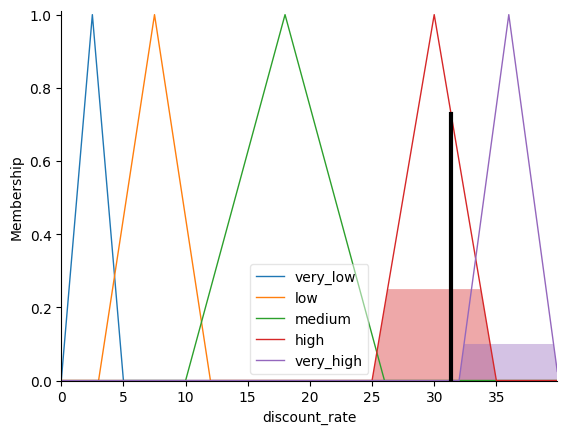

In [10]:
#Bài tập 2.13
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

product_demand = ctrl.Antecedent(np.arange(0, 100.1,0.1), 'product_demand')
pricing_pressure = ctrl.Antecedent(np.arange(0, 100.1,0.1), 'pricing_pressure')
store_reputation = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'store_reputation')
profit_margin = ctrl.Antecedent(np.arange(0, 60.1,0.1), 'profit_margin')
seasonal_demand = ctrl.Antecedent(np.arange(0, 11, 1), 'seasonal_demand')

discount_rate = ctrl.Consequent(np.arange(0, 40,0.1), 'discount_rate')

product_demand['low'] = fuzz.trimf(product_demand.universe, [0, 0, 50])
product_demand['medium'] = fuzz.trimf(product_demand.universe, [40, 60, 80])
product_demand['high'] = fuzz.trimf(product_demand.universe, [70, 100, 100])

pricing_pressure['low'] = fuzz.trimf(pricing_pressure.universe, [0, 0, 30])
pricing_pressure['medium'] = fuzz.trimf(pricing_pressure.universe, [20, 40, 60])
pricing_pressure['high'] = fuzz.trimf(pricing_pressure.universe, [50, 100, 100])

store_reputation['low'] = fuzz.trimf(store_reputation.universe, [0, 0, 4.0])
store_reputation['medium'] = fuzz.trimf(store_reputation.universe, [4, 4.3, 4.5])
store_reputation['high'] = fuzz.trimf(store_reputation.universe, [4.5, 5.0, 5.0])

profit_margin['low'] = fuzz.trimf(profit_margin.universe, [0, 0, 25])
profit_margin['medium'] = fuzz.trimf(profit_margin.universe, [20, 30, 40])
profit_margin['high'] = fuzz.trimf(profit_margin.universe, [35, 43, 50])

seasonal_demand['none'] = fuzz.trimf(seasonal_demand.universe, [0, 0, 3])
seasonal_demand['medium'] = fuzz.trimf(seasonal_demand.universe, [2, 4, 6])
seasonal_demand['high'] = fuzz.trimf(seasonal_demand.universe, [5, 10, 10])

discount_rate['very_low'] = fuzz.trimf(discount_rate.universe, [0, 2.5, 5])
discount_rate['low'] = fuzz.trimf(discount_rate.universe, [3, 7.5, 12])
discount_rate['medium'] = fuzz.trimf(discount_rate.universe, [10, 18, 26])
discount_rate['high'] = fuzz.trimf(discount_rate.universe, [25, 30 ,35 ])
discount_rate['very_high'] = fuzz.trimf(discount_rate.universe, [32, 36, 40])

rules = [
    ctrl.Rule(product_demand['high'] & pricing_pressure['low'] & profit_margin['low'], discount_rate['very_low']),
    ctrl.Rule(product_demand['low'] & pricing_pressure['high'] & profit_margin['high'], discount_rate['very_high']),
    ctrl.Rule(store_reputation['high'] & profit_margin['medium'] & seasonal_demand['high'], discount_rate['medium']),
    ctrl.Rule(pricing_pressure['high'] & seasonal_demand['high'] & profit_margin['high'], discount_rate['very_high']),
    ctrl.Rule(store_reputation['low'] & product_demand['medium'] & profit_margin['low'], discount_rate['medium']),
    ctrl.Rule(product_demand['high'] & seasonal_demand['none'] & pricing_pressure['low'], discount_rate['very_low']),
    ctrl.Rule(profit_margin['high'] & pricing_pressure['medium'] & seasonal_demand['medium'], discount_rate['medium']),
    ctrl.Rule(pricing_pressure['high'] & seasonal_demand['high'], discount_rate['very_high']),
    ctrl.Rule(product_demand['low'] & seasonal_demand['none'], discount_rate['medium']),
    ctrl.Rule(profit_margin['low'] & store_reputation['high'], discount_rate['very_low']),
    ctrl.Rule(product_demand['medium'] & pricing_pressure['medium'] & profit_margin['medium'], discount_rate['medium']),
    ctrl.Rule(profit_margin['high'] & pricing_pressure['medium'], discount_rate['high'])
]

discount_ctrl = ctrl.ControlSystem(rules)
simulation = ctrl.ControlSystemSimulation(discount_ctrl)

simulation.input['product_demand'] = 85
simulation.input['pricing_pressure'] = 55
simulation.input['store_reputation'] = 4.2
simulation.input['profit_margin'] = 45
simulation.input['seasonal_demand'] = 10

simulation.compute()

print(f"Recommended Discount Rate: {simulation.output['discount_rate']:.2f}%")
discount_rate.view(sim=simulation)

Số lượng đơn hàng cần kết hợp: 8.37
Mức độ ưu tiên giao hàng: 50.00%


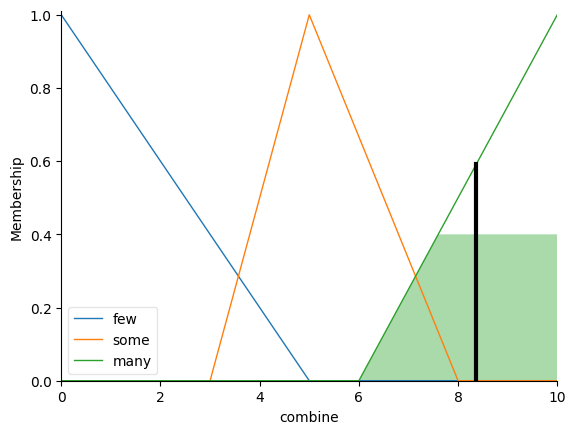

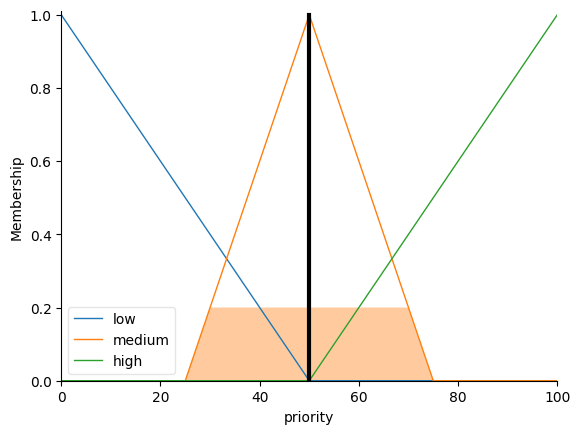

In [12]:
#Bài tập 2.14
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

density = ctrl.Antecedent(np.arange(0, 101, 1), 'density')
urgency = ctrl.Antecedent(np.arange(0, 101, 1), 'urgency')
load = ctrl.Antecedent(np.arange(0, 101, 1), 'load')
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
profit = ctrl.Antecedent(np.arange(0, 101, 1), 'profit')

combine = ctrl.Consequent(np.arange(0, 11, 1), 'combine')
priority = ctrl.Consequent(np.arange(0, 101, 1), 'priority')

density['low'] = fuzz.trimf(density.universe, [0, 0, 50])
density['medium'] = fuzz.trimf(density.universe, [25, 50, 75])
density['high'] = fuzz.trimf(density.universe, [50, 100, 100])

urgency['low'] = fuzz.trimf(urgency.universe, [0, 0, 50])
urgency['medium'] = fuzz.trimf(urgency.universe, [25, 50, 75])
urgency['high'] = fuzz.trimf(urgency.universe, [50, 100, 100])

load['low'] = fuzz.trimf(load.universe, [0, 0, 50])
load['medium'] = fuzz.trimf(load.universe, [25, 50, 75])
load['high'] = fuzz.trimf(load.universe, [50, 100, 100])

traffic['low'] = fuzz.trimf(traffic.universe, [0, 0, 50])
traffic['medium'] = fuzz.trimf(traffic.universe, [25, 50, 75])
traffic['high'] = fuzz.trimf(traffic.universe, [50, 100, 100])

profit['low'] = fuzz.trimf(profit.universe, [0, 0, 50])
profit['medium'] = fuzz.trimf(profit.universe, [25, 50, 75])
profit['high'] = fuzz.trimf(profit.universe, [50, 100, 100])

combine['few'] = fuzz.trimf(combine.universe, [0, 0, 5])
combine['some'] = fuzz.trimf(combine.universe, [3, 5, 8])
combine['many'] = fuzz.trimf(combine.universe, [6, 10, 10])

priority['low'] = fuzz.trimf(priority.universe, [0, 0, 50])
priority['medium'] = fuzz.trimf(priority.universe, [25, 50, 75])
priority['high'] = fuzz.trimf(priority.universe, [50, 100, 100])

rules = [
    ctrl.Rule(density['high'] & load['low'] & traffic['low'], combine['many']),
    ctrl.Rule(density['medium'] & traffic['high'] & urgency['medium'], combine['some']),
    ctrl.Rule(load['high'] & density['high'] & profit['medium'], combine['some']),
    ctrl.Rule(density['low'] & urgency['high'] & traffic['medium'], combine['some']),
    ctrl.Rule(profit['high'] & urgency['high'] & traffic['high'], combine['some']),
    ctrl.Rule(urgency['high'] & profit['high'], priority['high']),
    ctrl.Rule(urgency['medium'] & traffic['medium'], priority['medium']),
    ctrl.Rule(urgency['low'] & density['high'] & profit['low'], priority['low'])
]

logistics_ctrl = ctrl.ControlSystem(rules)
simulation = ctrl.ControlSystemSimulation(logistics_ctrl)

simulation.input['density'] = 85
simulation.input['urgency'] = 50
simulation.input['load'] = 20
simulation.input['traffic'] = 30
simulation.input['profit'] = 55

simulation.compute()

print(f"Số lượng đơn hàng cần kết hợp: {simulation.output['combine']:.2f}")
print(f"Mức độ ưu tiên giao hàng: {simulation.output['priority']:.2f}%")

combine.view(sim=simulation)
priority.view(sim=simulation)